# 2.1 Unsupervised Machine Learning - Dendogram

## Table of Contents
### 1. Import Libraries and Data
### 2. Data Wrangling
### 3. Dendograms - Valencia vs Heathrow
### 4. Dendograms - All Stations
### 5. PCA
### 6. Insights

## 1. Import Libraries and Data

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.pyplot import figure
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [13]:
# Import dataset
path = r'/Users/daxma/OneDrive/Desktop/Data Analytics/Machine Learning with Python/07-25 ClimateWins Analysis/02 Data'
climatedf = pd.read_csv(os.path.join(path, 'Prepared Data', 'weather_prediction_scaled_new.csv'))

In [15]:
# Check output
climatedf.head()

,Unnamed: 0,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,...,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,0,19600101,1,0.660514,-0.02793,0.826097,-0.001949,-1.101066,-0.265148,-0.179228,...,-0.443701,0.761754,-1.299744,-0.806427,-0.088407,-0.024706,0.372147,-0.668215,-0.519743,-0.752237
1,1,19600102,1,0.244897,-0.02793,0.735760,-0.001949,-1.058108,1.658760,-0.179228,...,0.783085,1.183580,-1.262455,-1.042055,0.503361,-0.024706,-0.829285,-0.548046,-0.629054,-0.407141
2,2,19600103,1,1.076130,-0.02793,1.277781,-0.001949,-1.251420,0.155707,-0.179228,...,0.783085,1.183580,-0.432779,-1.136306,-0.396127,-0.024706,-1.009500,-0.067372,0.054135,-0.177078
3,3,19600104,1,-1.001953,-0.02793,1.458455,-0.001949,-0.821838,-0.445514,-0.179228,...,0.783085,0.480538,0.387574,-1.183432,0.669056,-0.024706,-1.039536,-0.998679,-0.164486,-0.838511
4,4,19600105,1,0.244897,-0.02793,1.729466,-0.001949,-0.746661,-0.164944,-0.179228,...,-1.670486,-0.363113,1.729970,-0.794645,-0.490810,-0.024706,0.672505,-1.509396,-1.339569,-1.471186


In [17]:
# Import Pleasant Weather Answers Data
pleasant = pd.read_csv(os.path.join(path, 'Original Data', 'Pleasant_Weather_Answers.csv'))

In [19]:
# Check output
pleasant.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 2. Data Wrangling

#### Reduce data set to the year 2020

In [27]:
#Reduce your dataset to a single year 2020

climate2020 = climatedf[climatedf['DATE'].astype(str).str.contains('2020')] 
climate2020

,Unnamed: 0,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,...,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
762,762,19620201,2,1.076130,-0.02793,-0.077273,-0.001949,-1.176243,0.396196,-0.179228,...,0.169692,-1.066155,1.729970,-0.582580,-0.194926,-0.024706,0.041753,-1.088805,-0.820346,-1.212364
763,763,19620202,2,0.660514,-0.02793,0.735760,-0.001949,-0.972191,-0.225066,1.316146,...,1.396477,0.902363,1.646070,-1.065618,-0.123914,-0.024706,-1.039536,-0.698257,-0.492416,-0.867269
764,764,19620203,2,0.660514,-0.02793,0.645423,-0.001949,-0.757400,-0.445514,0.817688,...,0.783085,0.480538,0.937583,-0.829990,-0.135749,-0.024706,-0.829285,-0.578088,-0.383106,-0.752237
765,765,19620204,2,1.076130,-0.02793,1.097107,-0.001949,-1.165503,-0.124863,0.817688,...,1.396477,0.761754,0.322318,-1.100962,-0.242267,-0.024706,-1.039536,-0.457920,-0.328451,-0.493415
766,766,19620205,2,0.244897,-0.02793,0.013064,-0.001949,-1.090326,-0.425473,0.319230,...,0.783085,-0.644330,0.788428,-0.947804,-0.265938,-0.024706,-1.039536,-0.337751,-0.027848,-0.665963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22681,22681,20220205,2,-1.001953,-0.02793,-0.348283,1.388900,-0.381516,-0.445514,-0.179228,...,-0.443701,-0.081896,-0.003958,-0.005290,-0.005560,-0.024706,-0.018319,-0.007287,-0.000520,-0.004530
22682,22682,20220206,2,1.076130,-0.02793,-1.070979,0.303732,-1.111806,0.736888,-0.179228,...,-0.443701,-0.081896,-0.003958,-0.005290,-0.005560,-0.024706,-0.018319,-0.007287,-0.000520,-0.004530
22683,22683,20220207,2,-1.417570,-0.02793,-0.980642,1.450037,-0.435214,-0.445514,-0.179228,...,-0.443701,-0.081896,-0.003958,-0.005290,-0.005560,-0.024706,-0.018319,-0.007287,-0.000520,-0.004530
22684,22684,20220208,2,-1.417570,-0.02793,-1.251652,2.581057,-0.166725,-0.445514,-0.179228,...,-0.443701,-0.081896,-0.003958,-0.005290,-0.005560,-0.024706,-0.018319,-0.007287,-0.000520,-0.004530


## 3. Dendogram - Valencia and Heathrow

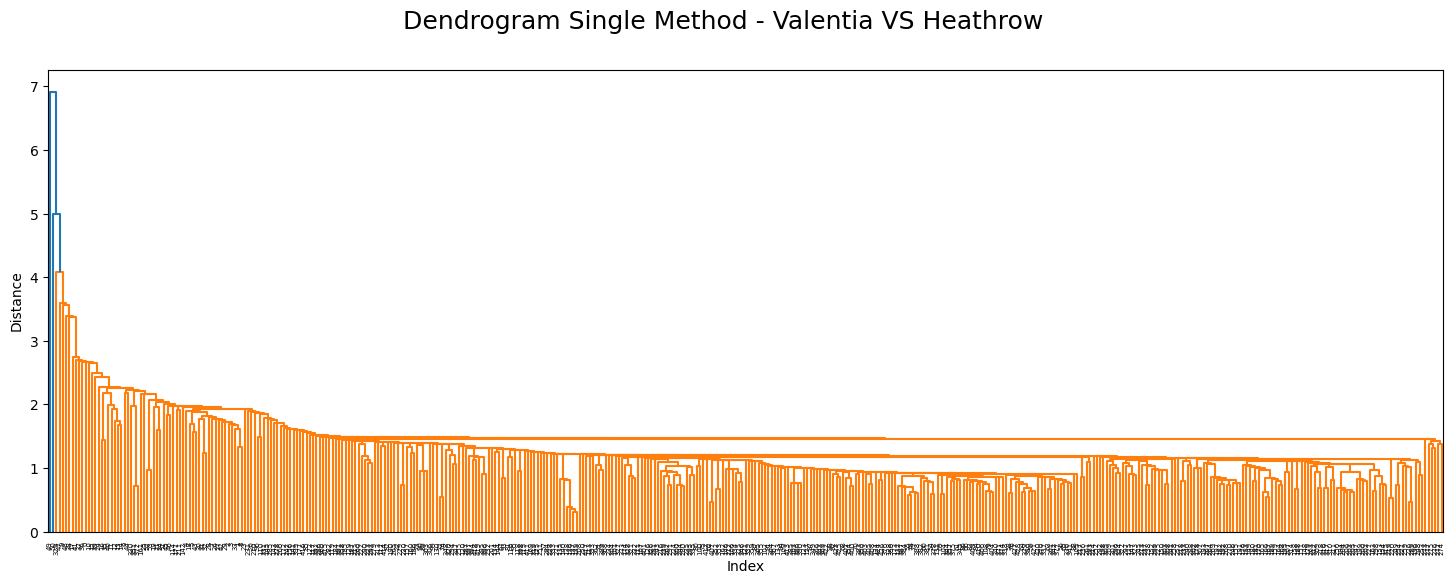

In [37]:
# Single method

columns_to_use = [
    'VALENTIA_cloud_cover', 'VALENTIA_humidity', 'VALENTIA_pressure',
    'VALENTIA_global_radiation', 'VALENTIA_precipitation', 'VALENTIA_snow_depth',
    'VALENTIA_sunshine', 'VALENTIA_temp_mean', 'VALENTIA_temp_min', 'VALENTIA_temp_max',
    'HEATHROW_cloud_cover', 'HEATHROW_humidity', 'HEATHROW_pressure',
    'HEATHROW_global_radiation', 'HEATHROW_precipitation', 'HEATHROW_snow_depth',
    'HEATHROW_sunshine', 'HEATHROW_temp_mean', 'HEATHROW_temp_min', 'HEATHROW_temp_max'
]

distance_single = linkage(climate2020[columns_to_use], method="single")
plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single Method - Valentia VS Heathrow", fontsize=18)
plt.show()


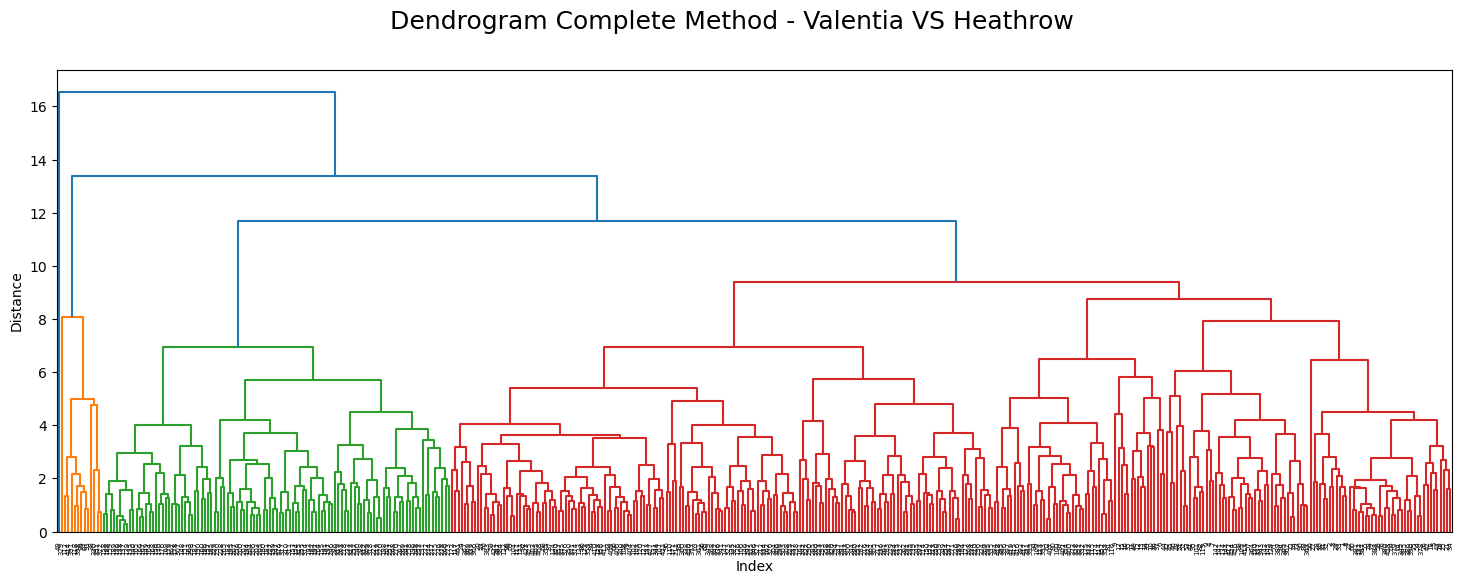

In [39]:
# Complete method

distance_complete = linkage(climate2020.loc[:, [
    'VALENTIA_cloud_cover',
    'VALENTIA_humidity',
    'VALENTIA_pressure',
    'VALENTIA_global_radiation',
    'VALENTIA_precipitation',
    'VALENTIA_snow_depth',
    'VALENTIA_sunshine',
    'VALENTIA_temp_mean',
    'VALENTIA_temp_min',
    'VALENTIA_temp_max',
    'HEATHROW_cloud_cover',
    'HEATHROW_humidity',
    'HEATHROW_pressure',
    'HEATHROW_global_radiation',
    'HEATHROW_precipitation',
    'HEATHROW_snow_depth',
    'HEATHROW_sunshine',
    'HEATHROW_temp_mean',
    'HEATHROW_temp_min',
    'HEATHROW_temp_max'
]], method="complete")

plt.figure(figsize=(18,6))
dendrogram(distance_complete, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Complete Method - Valentia VS Heathrow", fontsize=18)
plt.show()


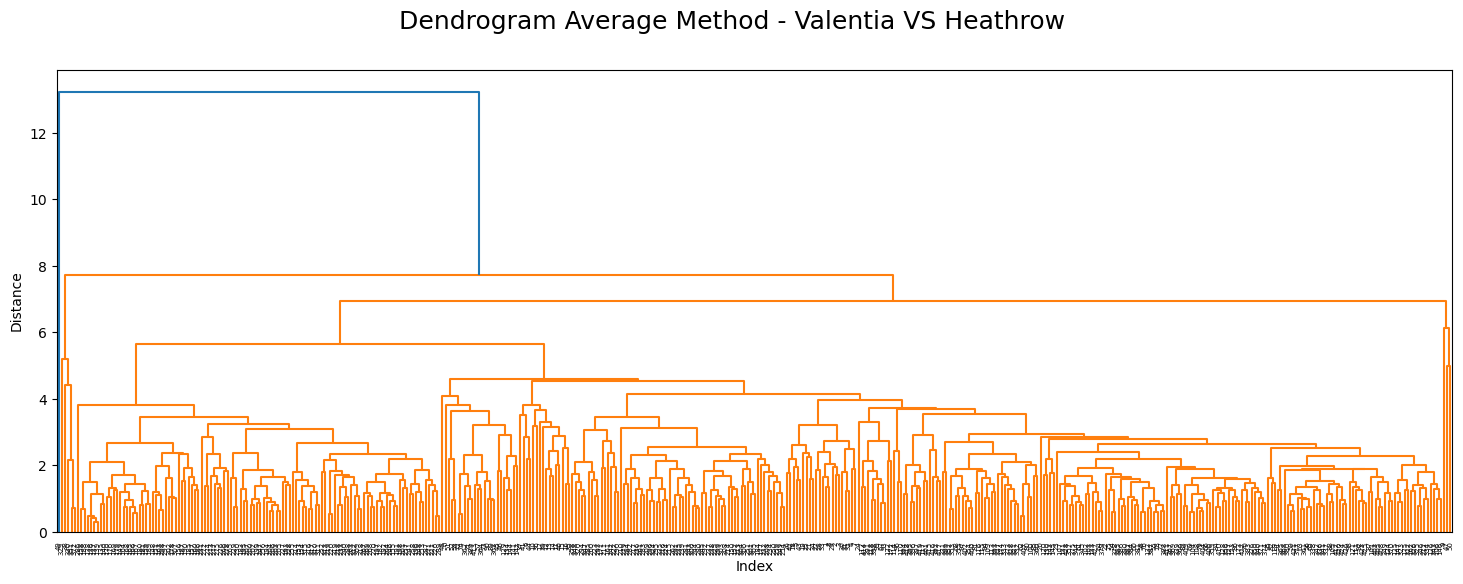

In [43]:
# Average method

distance_average = linkage(climate2020.loc[:, [
    'VALENTIA_cloud_cover',
    'VALENTIA_humidity',
    'VALENTIA_pressure',
    'VALENTIA_global_radiation',
    'VALENTIA_precipitation',
    'VALENTIA_snow_depth',
    'VALENTIA_sunshine',
    'VALENTIA_temp_mean',
    'VALENTIA_temp_min',
    'VALENTIA_temp_max',
    'HEATHROW_cloud_cover',
    'HEATHROW_humidity',
    'HEATHROW_pressure',
    'HEATHROW_global_radiation',
    'HEATHROW_precipitation',
    'HEATHROW_snow_depth',
    'HEATHROW_sunshine',
    'HEATHROW_temp_mean',
    'HEATHROW_temp_min',
    'HEATHROW_temp_max'
]], method="average")

plt.figure(figsize=(18,6))
dendrogram(distance_average, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Average Method - Valentia VS Heathrow", fontsize=18)
plt.show()


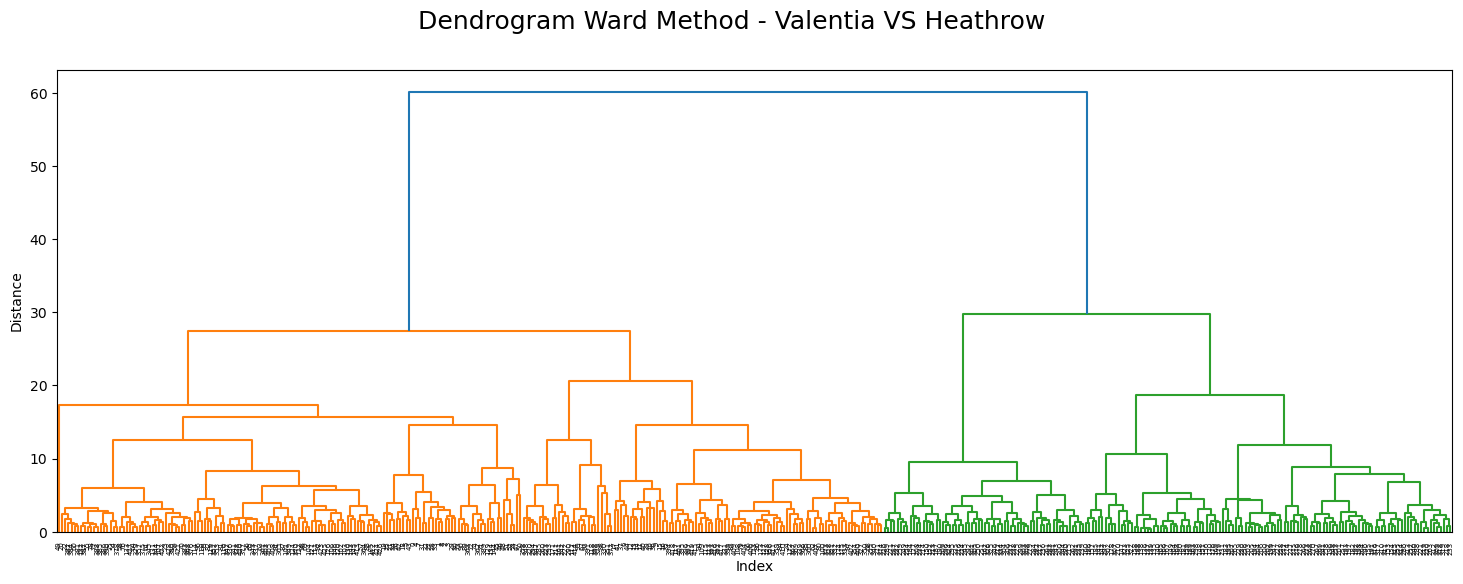

In [45]:
# Ward Method

distance_ward = linkage(climate2020.loc[:, [
    'VALENTIA_cloud_cover',
    'VALENTIA_humidity',
    'VALENTIA_pressure',
    'VALENTIA_global_radiation',
    'VALENTIA_precipitation',
    'VALENTIA_snow_depth',
    'VALENTIA_sunshine',
    'VALENTIA_temp_mean',
    'VALENTIA_temp_min',
    'VALENTIA_temp_max',
    'HEATHROW_cloud_cover',
    'HEATHROW_humidity',
    'HEATHROW_pressure',
    'HEATHROW_global_radiation',
    'HEATHROW_precipitation',
    'HEATHROW_snow_depth',
    'HEATHROW_sunshine',
    'HEATHROW_temp_mean',
    'HEATHROW_temp_min',
    'HEATHROW_temp_max'
]], method="ward")

plt.figure(figsize=(18,6))
dendrogram(distance_ward, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Ward Method - Valentia VS Heathrow", fontsize=18)
plt.show()


## 4. Dendogram - All Stations

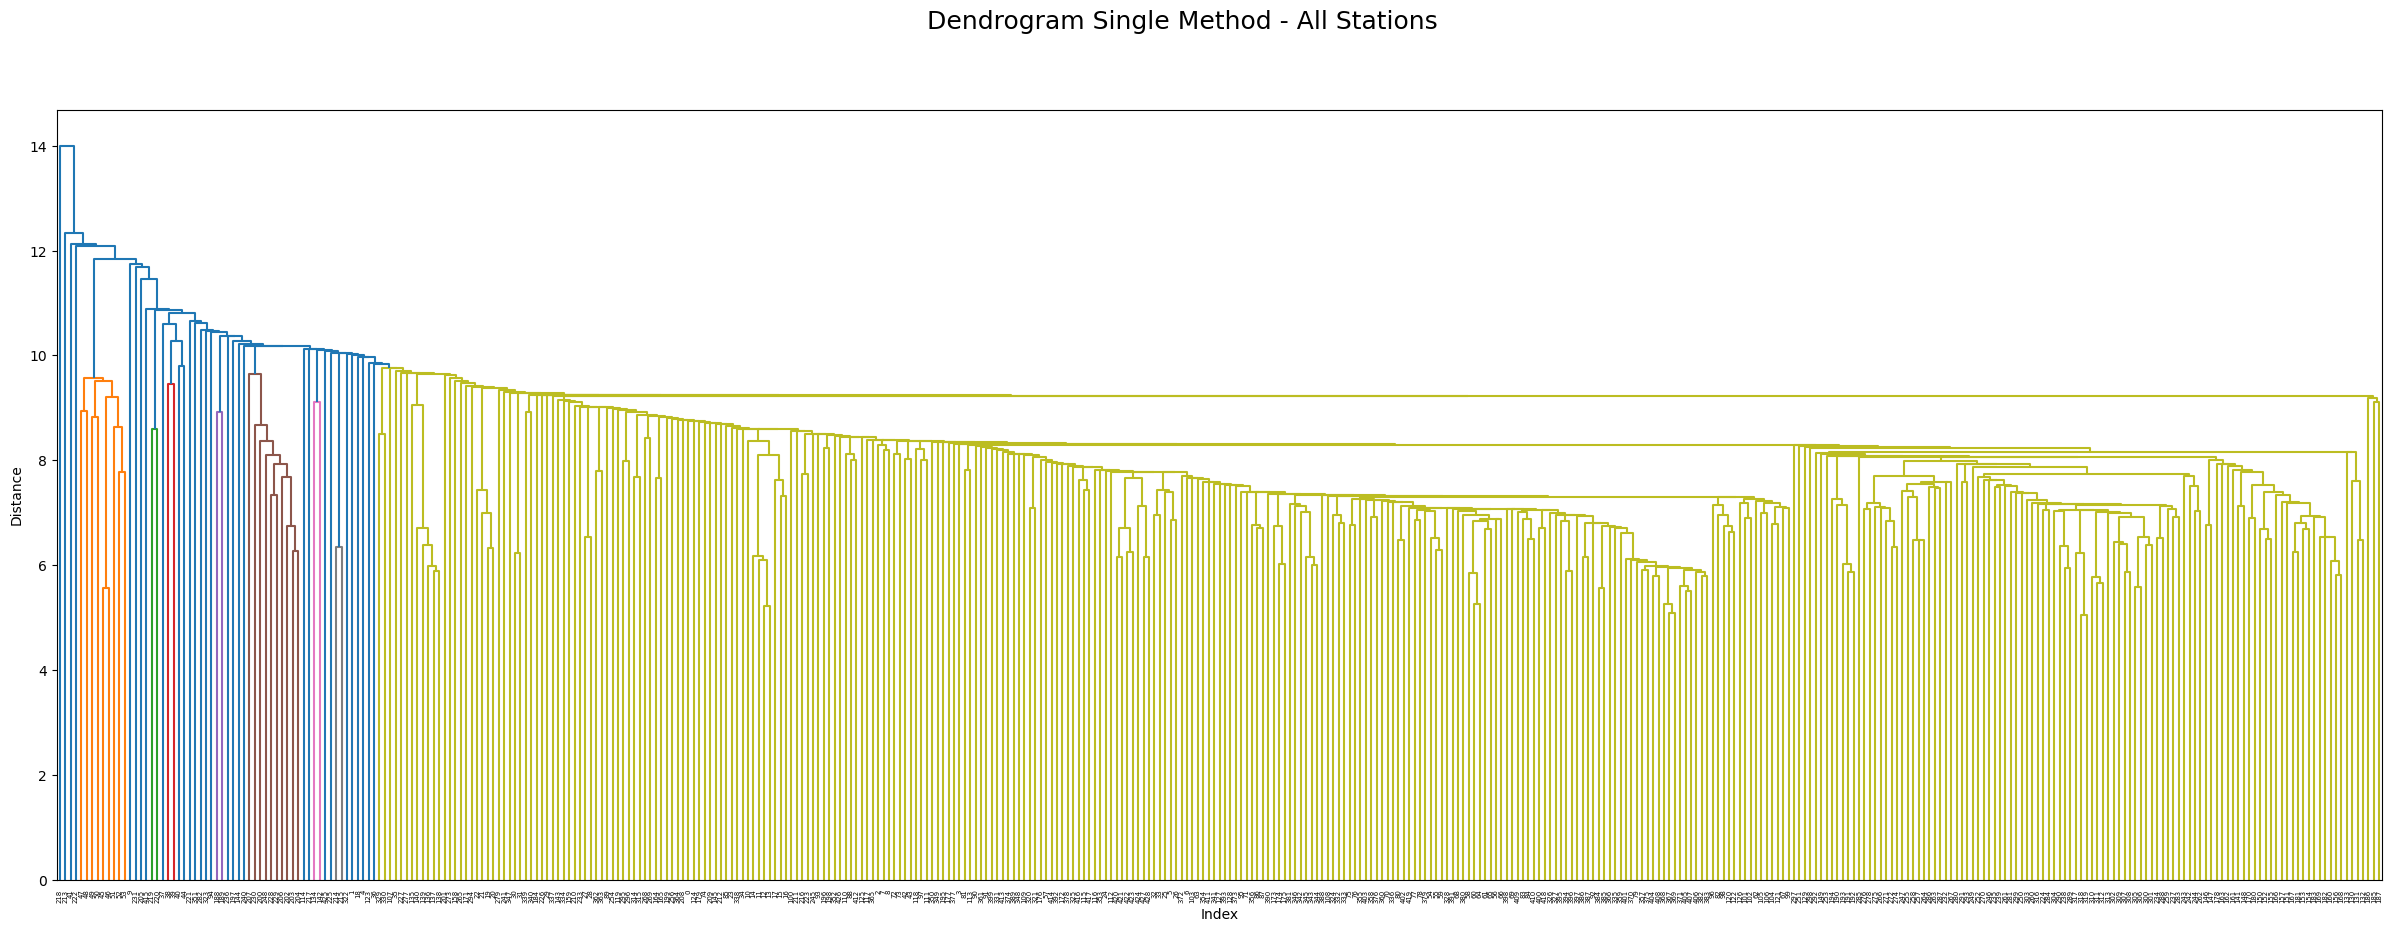

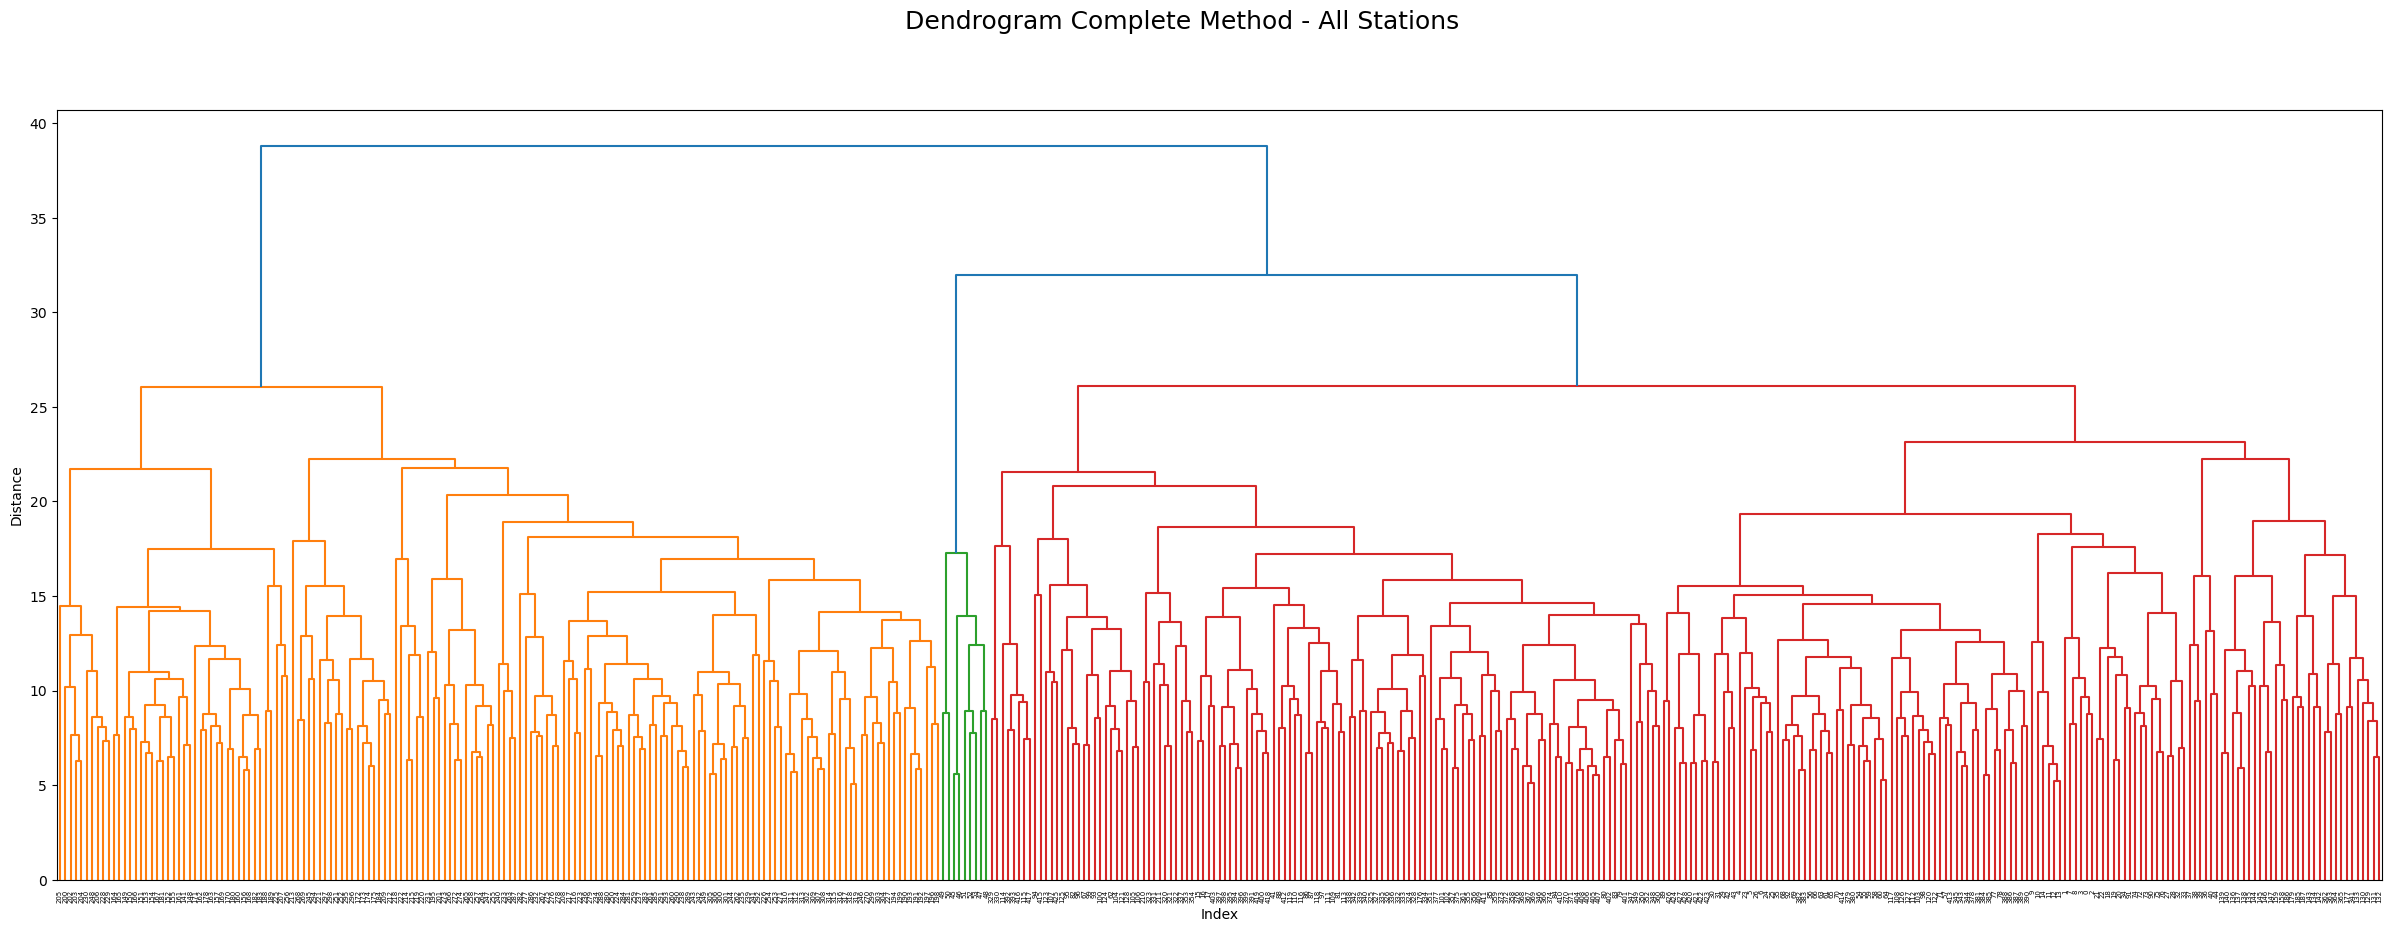

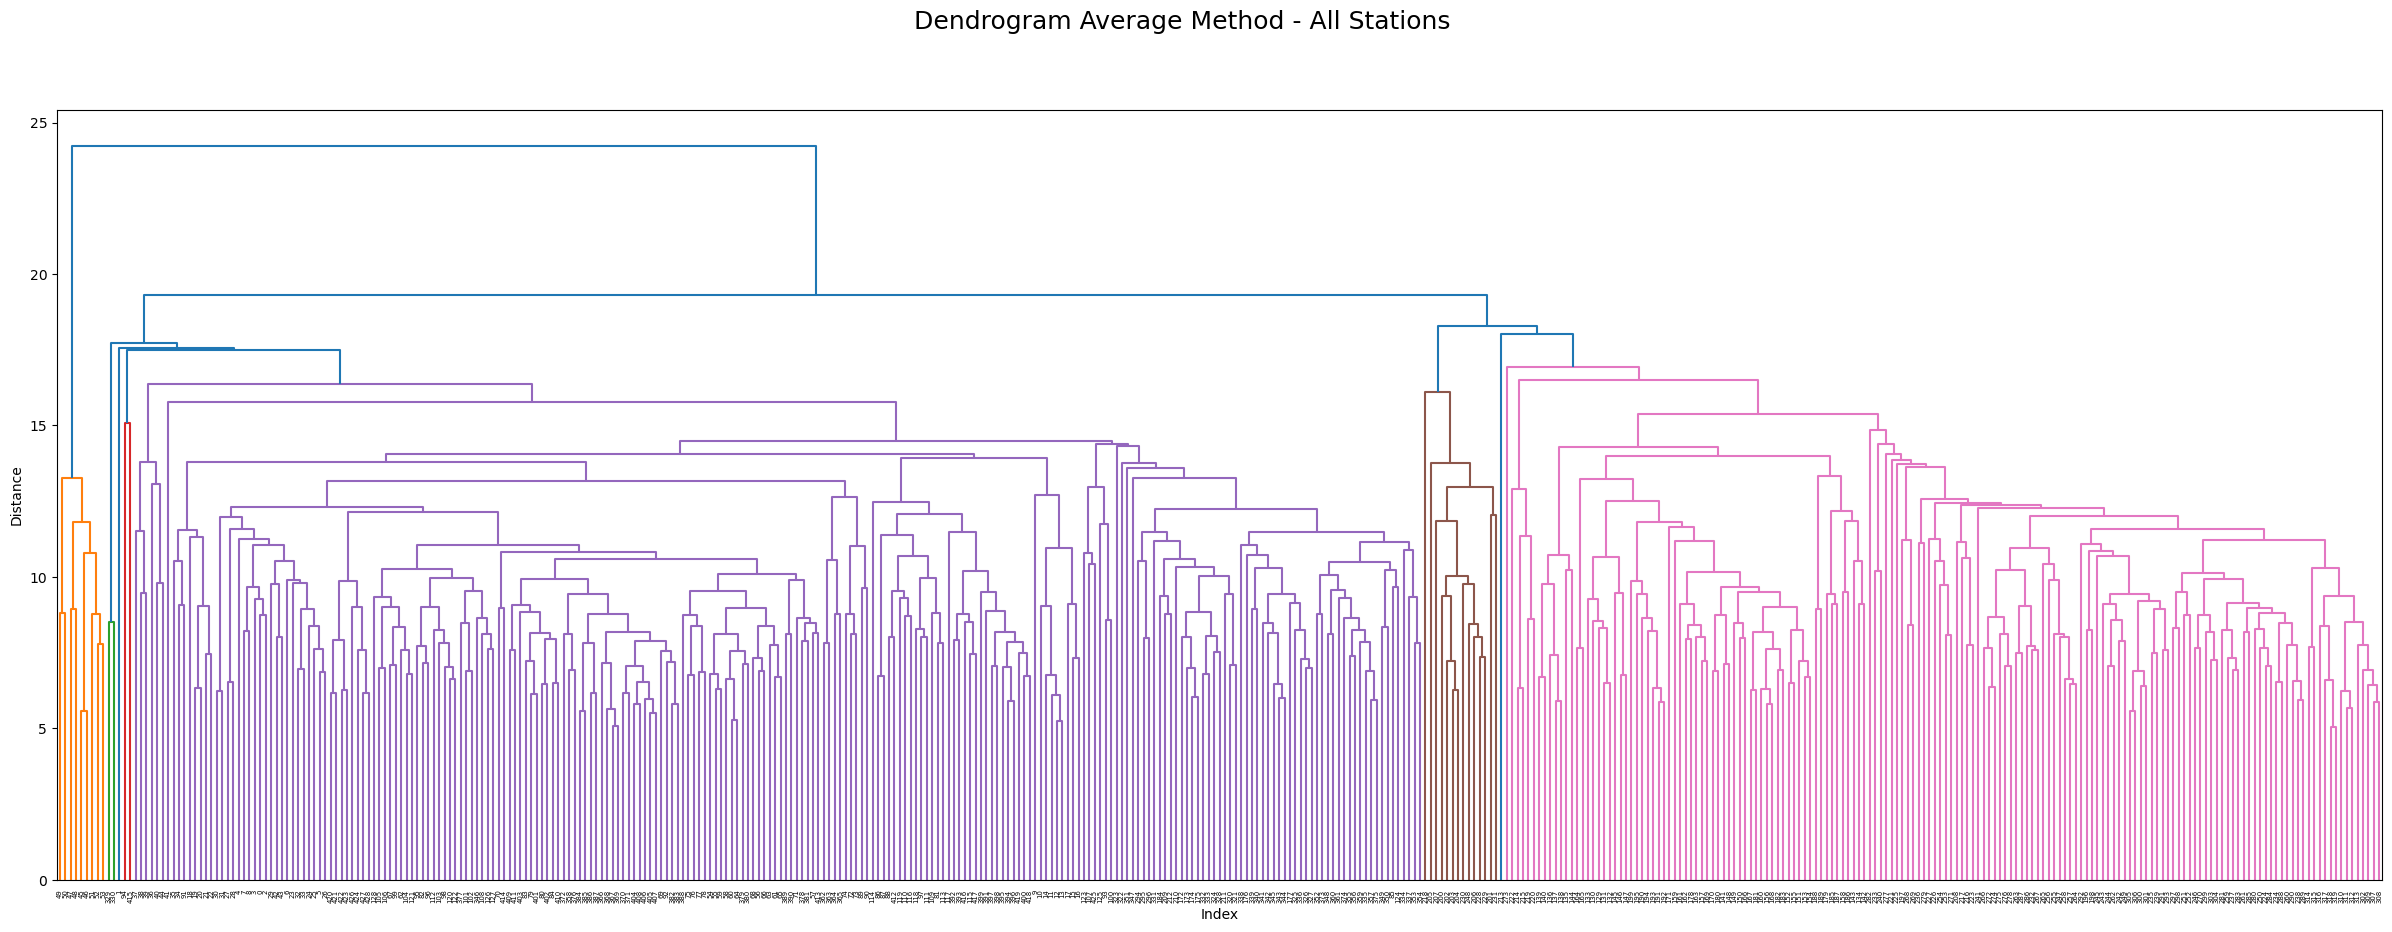

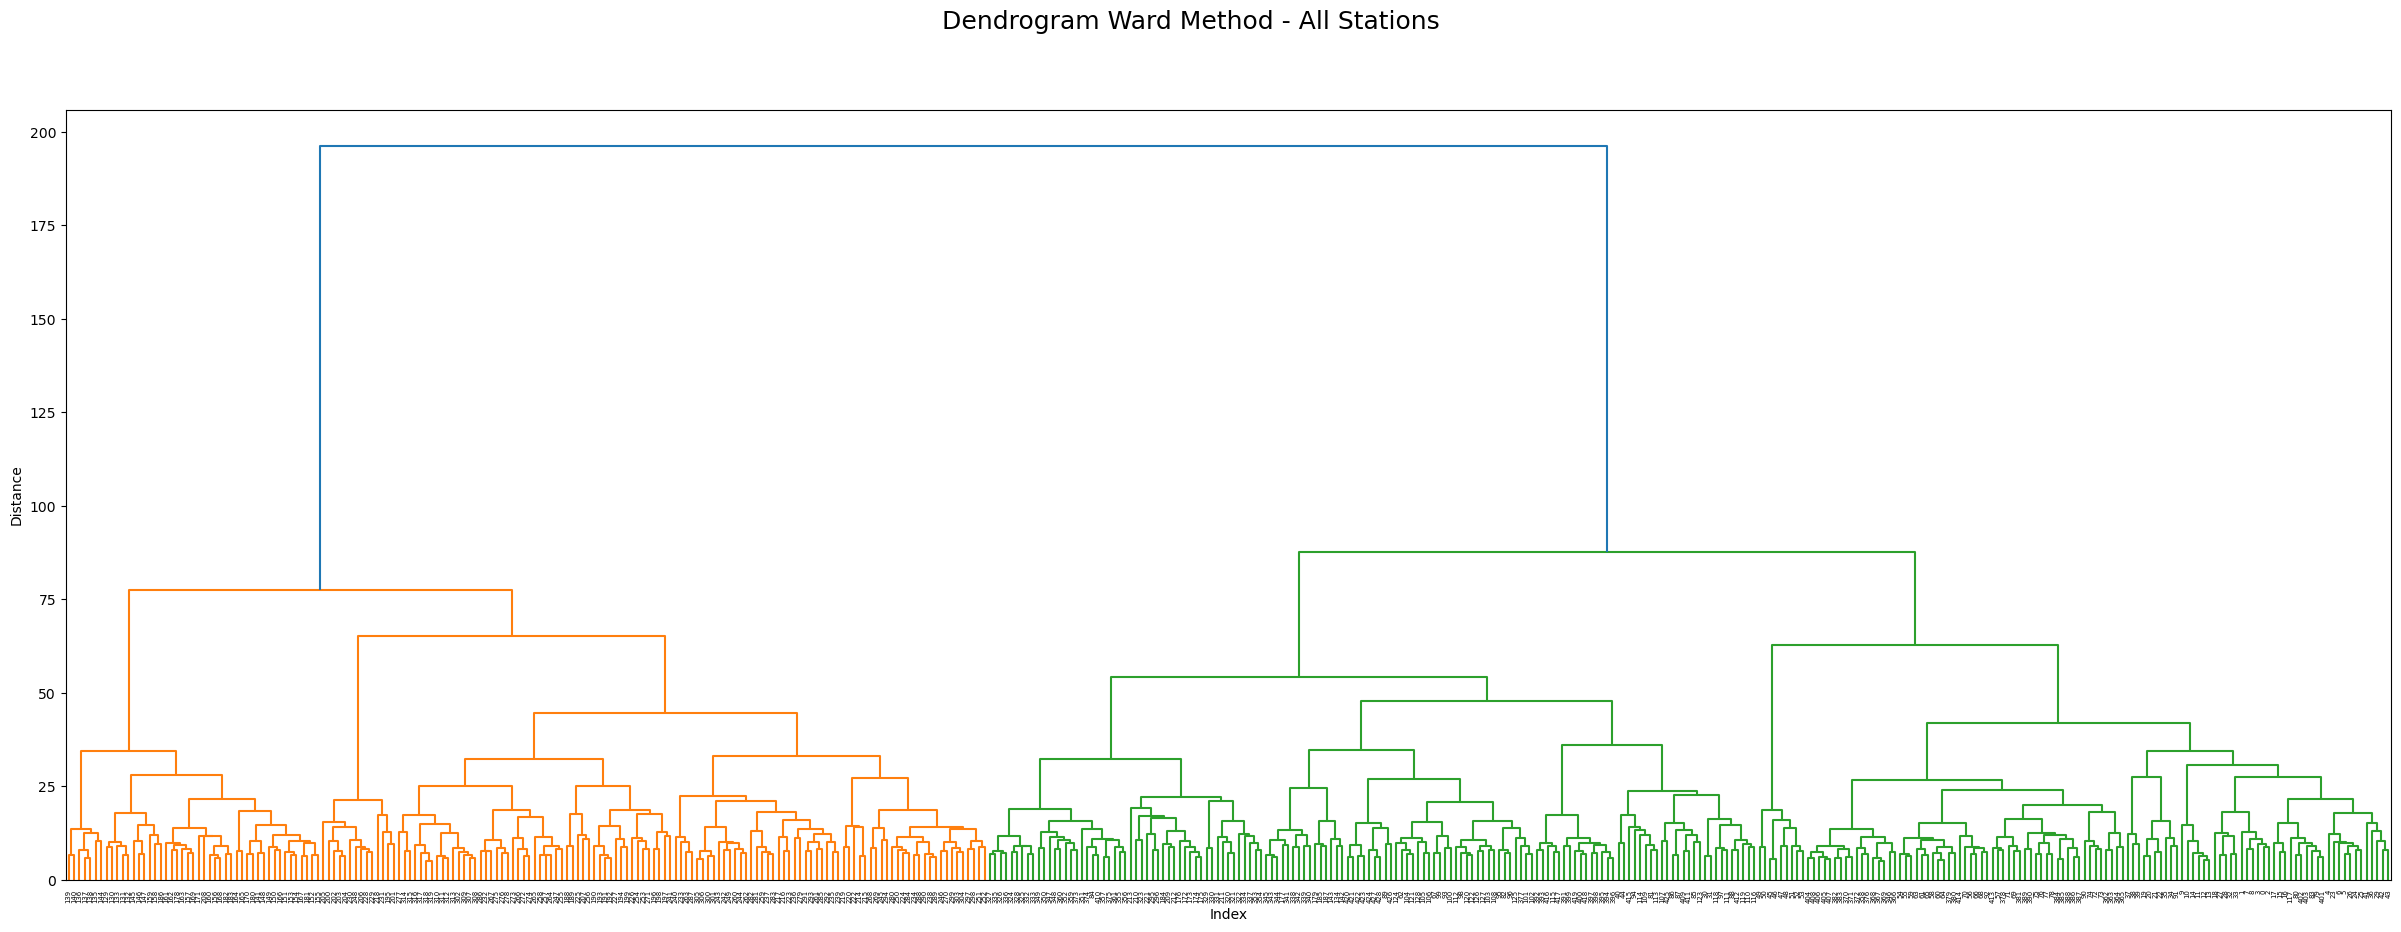

In [48]:
# Select all weather feature columns dynamically (skip index/date/month)
cols_all_stations = [col for col in climate2020.columns if col not in ['Unnamed: 0', 'DATE', 'MONTH']]

# Function to plot dendrograms for different methods
def plot_dendrogram(method_name):
    distance_matrix = linkage(climate2020[cols_all_stations], method=method_name)
    plt.figure(figsize=(30,10))
    dendrogram(distance_matrix, leaf_rotation=90)
    plt.xlabel('Index')
    plt.ylabel('Distance')
    plt.suptitle(f"Dendrogram {method_name.capitalize()} Method - All Stations", fontsize=18)
    plt.show()

# Run for all methods
for method in ["single", "complete", "average", "ward"]:
    plot_dendrogram(method)


## 5. PCA

In [51]:
# Select only weather-related columns (exclude date/index fields)
cols_all_stations = [col for col in climate2020.columns if col not in ['Unnamed: 0', 'DATE', 'MONTH']]

# Run PCA model, reducing to 9 components
pca = PCA(n_components=9)
principalComponents = pca.fit_transform(climate2020[cols_all_stations])

# Create a DataFrame for PCA results
dfPCA = pd.DataFrame(principalComponents, columns=['PCA1', 'PCA2', 'PCA3', 'PCA4', 'PCA5', 'PCA6', 'PCA7', 'PCA8', 'PCA9'])

# View results
dfPCA

,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9
0,-12.265105,2.846705,-3.040085,-1.598306,1.021537,-0.464763,2.673393,1.989726,1.582361
1,-11.605655,2.999673,-2.296827,-4.588444,0.230825,-0.746229,2.510591,1.577430,3.193006
2,-12.056563,1.114691,-0.838201,-3.020381,-0.026579,-0.145433,3.471051,2.571364,2.290370
3,-10.065589,0.718798,-0.654489,-2.261898,1.988739,1.405527,1.259309,0.326645,3.133785
4,-7.653545,0.190924,-2.049461,0.329553,2.869812,3.574059,0.061663,3.347828,1.582940
...,...,...,...,...,...,...,...,...,...
424,-4.840410,2.534232,0.566839,1.360573,2.765914,-0.424615,-0.005371,0.827728,-0.436120
425,-6.208423,-3.231991,-1.499633,1.909512,6.134626,0.656318,0.062293,-1.268745,1.049545
426,-4.179273,2.706109,-1.889455,-1.432173,5.151104,-1.226245,-1.917231,1.574621,-0.036494
427,-4.148079,2.904947,3.138554,-0.302000,5.713287,-1.718788,0.421073,0.091004,0.407591


In [53]:
# Export PCA results to CSV
dfPCA.to_csv(os.path.join(path, 'Prepared Data', '2020_PCA.csv'), index=False)

## 6. Insights

**Valentia vs Heathrow – Two Station Analysis**  
The single linkage method shows many short distance linkages between observations which indicates that daily weather profiles for these two stations are often very similar. The chaining effect is prominent which suggests a gradual merging of days with continuous variation rather than clear separation.  
The complete linkage method reveals three to four main groupings appearing at higher distance thresholds of around 8 to 16. This points to periods where Valentia and Heathrow experience more distinct weather differences.  
The average linkage method produces clusters that are more separated than in the single method but less extreme than in complete linkage. This reflects an intermediate level of variation and is better at showing general group patterns.  
The Ward method produces two dominant and very distinct clusters that split at a much higher distance threshold of around 60. This strong separation is likely due to seasonal differences such as winter versus summer conditions.

**All Stations Analysis**  
The single linkage method again shows a chaining effect with gradual merging of days across all stations. This indicates that many days share similar weather conditions, although a few outliers exist that merge at higher distances.  
The complete linkage method reveals three to four larger clusters forming at distances between 25 and 40. These clusters could correspond to broader European weather regimes such as cold and wet versus warm and dry conditions.  
The average linkage method displays a smoother and more balanced clustering structure that highlights smaller sub patterns within the data, possibly related to regional variations or transitional seasons.  
The Ward method generates the most distinct high level separation with two large clusters forming at very high distances of around 200. This suggests a primary division in the data that is likely driven by seasonal cycles or major regional climatic contrasts.

**Overall Observations**  
Seasonality appears to be the dominant factor influencing the clusters with a secondary influence from regional differences such as north versus south climates. Single linkage is most effective for detecting closely related daily conditions. Complete and average linkage are useful for identifying broader weather regimes. Ward linkage offers the clearest segmentation at the highest level, making it well suited for identifying major climatic divisions.